## ***Emotion Classification with RNN|  LSTMs & GRUs (PyTorch)***

- ***Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an **Advanced Bidirectional GRU** — implemented from scratch in **PyTorch**.***

In [ ]:
import re,os,pickle

from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
# dataset load karwane mai help karegi
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Load Dataset
Load the `dair-ai/emotion` dataset from Hugging Face.
https://huggingface.co/datasets/dair-ai/emotion

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
label_names = emotion_dataset['train'].features['label'].names

In [4]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [5]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [6]:
df_train.isnull().sum()

,0
text,0
label,0


### Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels.

In [7]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

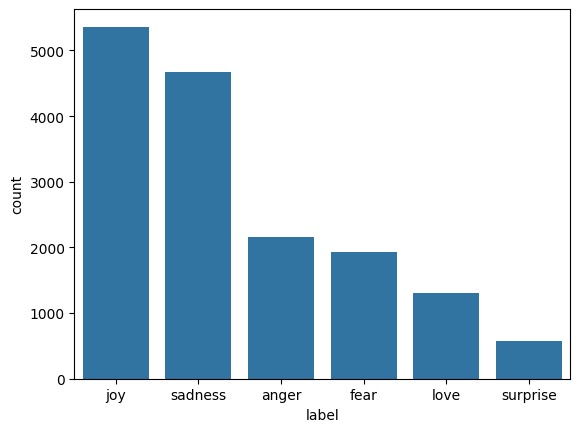

In [8]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [9]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


### Data Preprocessing Using NLP
Build a word-level vocabulary (the PyTorch equivalent of Keras' `Tokenizer`), tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [10]:
max_words = 10000
max_len   = 50

PAD_TOKEN = '<pad>'
OOV_TOKEN = '<unk>'

def simple_tokenize(text):
    # Lowercase + keep only words, mirrors Keras Tokenizer's default filtering
    return re.findall(r"[a-zA-Z']+", text.lower())

# Build vocabulary from the training text only (fit_on_texts equivalent)
word_counts = Counter()
for sentence in df_train['text']:
    word_counts.update(simple_tokenize(sentence))

# Keep the most common (max_words - 2) words, reserving 2 slots for <pad>/<unk>
most_common = word_counts.most_common(max_words - 2)

word_index = {PAD_TOKEN: 0, OOV_TOKEN: 1}
for word, _ in most_common:
    word_index[word] = len(word_index)

vocab_size = len(word_index)

def texts_to_sequences(texts):
    sequences = []
    for sentence in texts:
        seq = [word_index.get(tok, word_index[OOV_TOKEN]) for tok in simple_tokenize(sentence)]
        sequences.append(seq)
    return sequences

def pad_sequences(sequences, maxlen, padding='post', truncating='post'):
    padded = np.zeros((len(sequences), maxlen), dtype=np.int64)
    for i, seq in enumerate(sequences):
        if len(seq) > maxlen:
            seq = seq[:maxlen] if truncating == 'post' else seq[-maxlen:]
        if padding == 'post':
            padded[i, :len(seq)] = seq
        else:
            padded[i, -len(seq):] = seq
    return padded

train_sequence = texts_to_sequences(df_train['text'])
test_sequenece = texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen=max_len, padding='post', truncating='post')
padded_test_sequence  = pad_sequences(test_sequenece,  maxlen=max_len, padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {vocab_size}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 10000
Max Sentence Length: 50


### Shared Training Utilities
- ***Compute balanced class weights to handle dataset skew, wrap the data in `Dataset`/`DataLoader` objects, and implement an `EarlyStopping` helper (PyTorch has no built-in callback like Keras).***

In [11]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict   = dict(enumerate(class_weights))
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

In [12]:
class EmotionDataset(Dataset):
    """Wraps padded token sequences + labels for use with a DataLoader."""
    def __init__(self, sequences, labels):
        self.sequences = torch.as_tensor(sequences, dtype=torch.long)
        self.labels    = torch.as_tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


batch_size = 32

train_dataset = EmotionDataset(padded_train_sequence, train_labels)
test_dataset  = EmotionDataset(padded_test_sequence, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [13]:
class EarlyStopping:
    """PyTorch equivalent of tf.keras.callbacks.EarlyStopping
    (monitor='val_loss', patience=3, restore_best_weights=True)."""
    def __init__(self, patience=3, restore_best_weights=True):
        self.patience = patience
        self.restore_best_weights = restore_best_weights
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

    def restore(self, model):
        if self.restore_best_weights and self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_model(model, train_loader, val_loader, epochs=20, class_weights=None, patience=3):
    """Generic training loop mirroring model.fit(..., callbacks=[early_stopping])."""
    model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters())
    early_stopping = EarlyStopping(patience=patience, restore_best_weights=True)

    for epoch in range(epochs):
        model.train()
        running_loss, running_correct, seen = 0.0, 0, 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x_batch.size(0)
            running_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            seen += x_batch.size(0)

        train_loss = running_loss / seen
        train_acc  = running_correct / seen

        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        early_stopping.step(val_loss, model)
        if early_stopping.should_stop:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

    early_stopping.restore(model)
    return model


def evaluate_model(model, data_loader, criterion=None):
    """Mirrors model.evaluate(...) -> (loss, accuracy)."""
    model.eval()
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    running_loss, running_correct, seen = 0.0, 0, 0
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * x_batch.size(0)
            running_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            seen += x_batch.size(0)

    return running_loss / seen, running_correct / seen


def predict_model(model, data_loader):
    """Mirrors model.predict(...) -> argmax class predictions."""
    model.eval()
    preds = []
    with torch.no_grad():
        for x_batch, _ in data_loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)

### Plain Foundational Models
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

### Model 1: Simple RNN
Plain unrolled Recurrent Neural Network.

In [14]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn1 = nn.RNN(embed_dim, 128, batch_first=True)
        self.dropout1 = nn.Dropout(0.5)
        self.rnn2 = nn.RNN(128, 64, batch_first=True)
        self.dropout2 = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_classes)  # Output Layer

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.rnn1(x)          # return_sequences=True
        x = self.dropout1(x)
        _, hn = self.rnn2(x)         # return_sequences=False -> take final hidden state
        x = self.dropout2(hn[-1])
        return self.fc(x)            # logits (softmax handled by CrossEntropyLoss)


rnn_model = SimpleRNNClassifier(vocab_size=vocab_size, embed_dim=128, num_classes=num_classes).to(device)
print(rnn_model)

SimpleRNNClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (rnn1): RNN(128, 128, batch_first=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (rnn2): RNN(128, 64, batch_first=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


In [15]:
rnn_model = train_model(rnn_model, train_loader, test_loader, epochs=20,
                         class_weights=class_weights_tensor, patience=3)

rnn_loss, rnn_accuracy = evaluate_model(rnn_model, test_loader)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20 - loss: 1.7981 - accuracy: 0.2034 - val_loss: 1.7957 - val_accuracy: 0.1120
Epoch 2/20 - loss: 1.7901 - accuracy: 0.1990 - val_loss: 1.7966 - val_accuracy: 0.1255
Epoch 3/20 - loss: 1.8190 - accuracy: 0.1867 - val_loss: 1.7980 - val_accuracy: 0.1180
Epoch 4/20 - loss: 1.8068 - accuracy: 0.1741 - val_loss: 1.8089 - val_accuracy: 0.0405
Early stopping triggered at epoch 4.
RNN Loss: 1.8021093654632567
RNN Accuracy: 0.112


### Model 2: Standard LSTM
Plain stacked Long Short-Term Memory network.

In [16]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm1 = nn.LSTM(embed_dim, 128, batch_first=True)
        self.dropout1 = nn.Dropout(0.5)
        self.lstm2 = nn.LSTM(128, 64, batch_first=True)
        self.dropout2 = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_classes)  # Output Layer

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm1(x)                 # return_sequences=True
        x = self.dropout1(x)
        _, (hn, cn) = self.lstm2(x)          # return_sequences=False -> final hidden state
        x = self.dropout2(hn[-1])
        return self.fc(x)


lstm_model = LSTMClassifier(vocab_size=vocab_size, embed_dim=128, num_classes=num_classes).to(device)

lstm_model = train_model(lstm_model, train_loader, test_loader, epochs=20,
                          class_weights=class_weights_tensor, patience=3)

lstm_loss, lstm_accuracy = evaluate_model(lstm_model, test_loader)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20 - loss: 1.7923 - accuracy: 0.2020 - val_loss: 1.7892 - val_accuracy: 0.2880
Epoch 2/20 - loss: 1.7914 - accuracy: 0.2389 - val_loss: 1.7899 - val_accuracy: 0.3430
Epoch 3/20 - loss: 1.7907 - accuracy: 0.2316 - val_loss: 1.7927 - val_accuracy: 0.1120
Epoch 4/20 - loss: 1.7861 - accuracy: 0.2175 - val_loss: 1.7918 - val_accuracy: 0.0840
Early stopping triggered at epoch 4.
LSTM Loss: 1.7586144876480103
LSTM Accuracy: 0.288


### Model 3: Standard GRU
Plain stacked Gated Recurrent Unit network.

In [17]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru1 = nn.GRU(embed_dim, 128, batch_first=True)
        self.dropout1 = nn.Dropout(0.5)
        self.gru2 = nn.GRU(128, 64, batch_first=True)
        self.dropout2 = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_classes)  # Output Layer

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.gru1(x)          # return_sequences=True
        x = self.dropout1(x)
        _, hn = self.gru2(x)         # return_sequences=False -> final hidden state
        x = self.dropout2(hn[-1])
        return self.fc(x)


gru_model = GRUClassifier(vocab_size=vocab_size, embed_dim=128, num_classes=num_classes).to(device)

gru_model = train_model(gru_model, train_loader, test_loader, epochs=20,
                         class_weights=class_weights_tensor, patience=3)

gru_loss, gru_accuracy = evaluate_model(gru_model, test_loader)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20 - loss: 1.7943 - accuracy: 0.2048 - val_loss: 1.7908 - val_accuracy: 0.1390
Epoch 2/20 - loss: 1.7898 - accuracy: 0.2224 - val_loss: 1.7921 - val_accuracy: 0.0810
Epoch 3/20 - loss: 1.7830 - accuracy: 0.2081 - val_loss: 1.7984 - val_accuracy: 0.0825
Epoch 4/20 - loss: 1.7706 - accuracy: 0.2078 - val_loss: 1.8063 - val_accuracy: 0.0495
Early stopping triggered at epoch 4.
GRU Loss: 1.7792424945831298
GRU Accuracy: 0.139


### Ranking & Selection
Rank foundational models to pick the best base cell for Phase 2.

In [18]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy', ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,1.758614,0.288
2,GRU,1.779242,0.139
0,RNN,1.802109,0.112


### Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

###  Advanced Stacked Bidirectional GRU

In [19]:
class BiGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru1 = nn.GRU(embed_dim, 128, batch_first=True, bidirectional=True)
        self.dropout1 = nn.Dropout(0.5)
        # input size is 128*2 because gru1 is bidirectional (forward + backward concatenated)
        self.gru2 = nn.GRU(128 * 2, 64, batch_first=True, bidirectional=True)
        self.dropout2 = nn.Dropout(0.5)
        self.fc = nn.Linear(64 * 2, num_classes)  # Output Layer

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.gru1(x)                       # return_sequences=True
        x = self.dropout1(x)
        _, hn = self.gru2(x)                      # return_sequences=False
        # hn: (num_directions, batch, hidden) for the last layer -> concat fwd/bwd
        x = torch.cat((hn[-2], hn[-1]), dim=1)
        x = self.dropout2(x)
        return self.fc(x)

BiGRU = BiGRUClassifier(vocab_size=vocab_size, embed_dim=300, num_classes=num_classes).to(device)
print(BiGRU)

n_params = sum(p.numel() for p in BiGRU.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

BiGRUClassifier(
  (embedding): Embedding(10000, 300, padding_idx=0)
  (gru1): GRU(300, 128, batch_first=True, bidirectional=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (gru2): GRU(256, 64, batch_first=True, bidirectional=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)
Trainable parameters: 3,454,662


#### Train & Evaluate Advanced Bidirectional GRU

In [20]:
BiGRU = train_model(BiGRU, train_loader, test_loader, epochs=20,
                     class_weights=class_weights_tensor, patience=3)

Epoch 1/20 - loss: 1.5952 - accuracy: 0.2818 - val_loss: 0.8945 - val_accuracy: 0.5810
Epoch 2/20 - loss: 0.5307 - accuracy: 0.7904 - val_loss: 0.3301 - val_accuracy: 0.8770
Epoch 3/20 - loss: 0.2377 - accuracy: 0.9137 - val_loss: 0.2757 - val_accuracy: 0.8960
Epoch 4/20 - loss: 0.1625 - accuracy: 0.9402 - val_loss: 0.2847 - val_accuracy: 0.9070
Epoch 5/20 - loss: 0.1180 - accuracy: 0.9546 - val_loss: 0.3071 - val_accuracy: 0.9085
Epoch 6/20 - loss: 0.0896 - accuracy: 0.9671 - val_loss: 0.3134 - val_accuracy: 0.9120
Early stopping triggered at epoch 6.


In [21]:
BiGRU_loss, BiGRU_accuracy = evaluate_model(BiGRU, test_loader)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

BiGRU Loss: 0.28635812625288964
BiGRU Accuracy: 0.896


### Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

### Final Model Confusion Matrices (Raw Counts & Normalized %)

In [22]:
# sadness=5%,joy=14%,anger=67%,love=9%,suprise=50%,fear=2%

<Axes: >

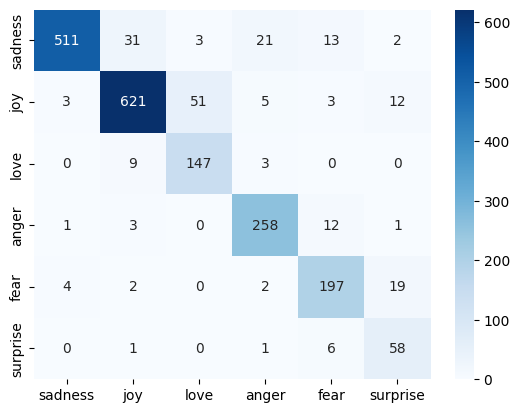

In [23]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = predict_model(BiGRU, test_loader)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions), annot=True, fmt='d',
            cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

## Final Predictions
Test the winning model on unseen sample sentences.

In [24]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=max_len, padding='post', truncating='post')

BiGRU.eval()
with torch.no_grad():
    sample_tensor = torch.as_tensor(sample_padded_sequences, dtype=torch.long).to(device)
    sample_logits = BiGRU(sample_tensor)
    sample_predictions = sample_logits.argmax(dim=1).cpu().numpy()

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


### Save Model & Tokenizer
Export trained model weights and the vocabulary for API deployment.

In [25]:
model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)  # yeh folder hai jiske andar sari exported file aane wali hai

# Save our BiGRU Model (weights + minimal config needed to rebuild the architecture)
torch.save({
    'model_state_dict': BiGRU.state_dict(),
    'vocab_size': vocab_size,
    'embed_dim': 300,
    'num_classes': num_classes,
}, os.path.join(model_dir, 'BiGRU_Model.pt'))

# Save the vocabulary (PyTorch equivalent of the Keras tokenizer)
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(word_index, file)